<a href="https://colab.research.google.com/github/Vikrant25122004/Skin-disease-detection-model/blob/main/Skin_disease_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unveiling the Future of Dermatology: An AI-Powered Skin Disease Detection Model

Welcome to a glimpse into the future of healthcare, where artificial intelligence is revolutionizing the way we approach medical diagnostics. This project introduces a cutting-edge Convolutional Neural Network (CNN) model specifically engineered for the rapid and accurate detection and classification of various skin diseases from medical images.

### The Challenge: A Critical Need for Timely Diagnosis
Skin diseases affect millions worldwide, ranging from benign conditions to life-threatening ailments like melanoma. The cornerstone of effective treatment lies in early and precise diagnosis. However, this process often relies on expert dermatologists, whose availability can be limited, particularly in underserved regions. This reliance can lead to delayed diagnoses, increased patient anxiety, and potentially worse health outcomes. Furthermore, human visual assessment, while highly skilled, can sometimes be subjective or prone to error due to the sheer volume and complexity of cases.

### Our Solution: Harnessing the Power of Deep Learning
Our model steps in as a powerful aid, designed to bridge this gap. By leveraging the advanced capabilities of deep learning, especially CNNs—a class of neural networks adept at image analysis—we've created a system that can 'learn' to identify subtle patterns and features indicative of different skin conditions. The model has been meticulously trained on a vast and diverse dataset of skin lesion images, covering a wide spectrum of common diseases. Each image has been carefully categorized, providing the model with the knowledge it needs to distinguish between various conditions.

### How It Works: A Peek Under the Hood
Before the images even reach the neural network, they undergo essential preprocessing steps, such as normalization. This ensures consistency and optimizes the data for the model's learning process. The core of our solution is a sophisticated CNN architecture, featuring multiple layers:

*   **Convolutional Layers:** These layers act like feature detectors, identifying edges, textures, and specific shapes within the skin images.
*   **Pooling Layers:** These layers progressively reduce the spatial dimensions of the data, helping to make the model more robust to variations in image position and scale.
*   **Batch Normalization:** This technique stabilizes and accelerates the training process, leading to a more reliable and higher-performing model.

To ensure peak performance, we've utilized `Keras Tuner` for hyperparameter optimization. This automated process intelligently explores various configurations, selecting the best activation functions and optimizers to maximize the model's accuracy and generalization capabilities across unseen images.

### The Impact: Transforming Dermatology
This AI-powered diagnostic tool holds immense potential:

*   **Enhanced Diagnostic Efficiency:** It can rapidly analyze images, providing quick preliminary assessments.
*   **Support for Clinicians:** It serves as a valuable second opinion or a screening tool, allowing dermatologists to focus on complex cases.
*   **Improved Accessibility:** It can extend diagnostic capabilities to remote areas, enabling earlier detection and intervention.
*   **Better Patient Outcomes:** By facilitating timely and accurate diagnoses, it contributes directly to more effective treatments and improved patient health.

In essence, this model represents a significant stride towards making advanced dermatological diagnostics more accessible, efficient, and precise, ultimately leading to a healthier future for all.



### A Wealth of Data: Fueling Precision

Our AI model has been meticulously trained and validated on a colossal dataset comprising **27,153 high-resolution medical images**. This extensive collection spans **10 distinct categories** of skin diseases, ensuring a comprehensive understanding of various dermatological conditions. This sheer volume and diversity of data are the bedrock of our model's impressive accuracy and its ability to generalize effectively across a wide spectrum of real-world scenarios, propelling us closer to a future of more precise and accessible skin diagnostics.

## Identified Skin Diseases:

*   Eczema
*   Warts Molluscum and other Viral Infections
*   Melanoma
*   Atopic Dermatitis
*   Basal Cell Carcinoma (BCC)
*   Melanocytic Nevi (NV)
*   Benign Keratosis-like Lesions (BKL)
*   Psoriasis pictures Lichen Planus and related diseases
*   Seborrheic Keratoses and other Benign Tumors
*   Tinea Ringworm Candidiasis and other Fungal Infections

### Model Strategy: Deep Learning for Dermatological Insights

Our AI-powered skin disease detection model employs a sophisticated Convolutional Neural Network (CNN) architecture, meticulously designed to identify subtle yet critical patterns within medical images. The core strategy involves several key components:

1.  **Preprocessing:** Images are first normalized to ensure consistency and optimize data for the model's learning process.
2.  **Multi-Layered CNN:** The model features several blocks, each consisting of:
    *   **Convolutional Layers:** These act as feature detectors, discerning edges, textures, and specific shapes indicative of various skin conditions.
    *   **Batch Normalization:** This technique stabilizes and accelerates training, leading to a more reliable and higher-performing model.
    *   **MaxPooling Layers:** These layers progressively reduce the spatial dimensions of the data, making the model more robust to variations in image position and scale.
3.  **Dropout Layers:** To prevent overfitting and enhance generalization, dropout layers are strategically placed, randomly deactivating a fraction of neurons during training.
4.  **Global Average Pooling:** This layer reduces the feature maps to a single vector, preparing the data for the final classification layers.
5.  **Dense Head:** A fully connected dense layer processes the learned features before the final output.
6.  **Hyperparameter Optimization with Keras Tuner:** To ensure peak performance, `Keras Tuner` was utilized for automated hyperparameter optimization. This process intelligently explored various configurations, selecting optimal activation functions for different layers and the best optimizer to maximize the model's accuracy and generalization capabilities across unseen images.

This comprehensive strategy allows the model to effectively learn, discern, and classify a wide spectrum of dermatological conditions from complex image data.

### Model Accuracy: A Testament to Performance

After rigorous training over 20 epochs, our model has achieved an impressive **accuracy of approximately 95.44%**. This high level of accuracy demonstrates the model's robust ability to correctly identify and classify various skin diseases within the diverse dataset. Such performance highlights its potential as a powerful and reliable tool for aiding dermatological diagnostics, offering significant promise for enhanced efficiency and improved patient care.

In [1]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vikrantsharma251111","key":"05ce06b9184db18884adde1cfb778ef4"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



In [3]:
#downloading data from kaggle
!kaggle datasets download ismailpromus/skin-diseases-image-dataset

Dataset URL: https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset
License(s): copyright-authors
100% 5.18G/5.19G [01:23<00:00, 52.6MB/s]
100% 5.19G/5.19G [01:23<00:00, 67.0MB/s]


In [4]:
#unzipping zip file
import zipfile

zip_path = "/content/skin-diseases-image-dataset.zip"
output_dir = "/content/unzipped"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(output_dir)

In [45]:
import keras
import matplotlib.pyplot as plt
# extracting images from folder with keras generator
dataset = keras.utils.image_dataset_from_directory(
    directory="/content/unzipped/IMG_CLASSES",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128,128),
    color_mode="rgb",
)


Found 27153 files belonging to 10 classes.


In [46]:
print(dataset.class_names)
# extracting all labels

['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


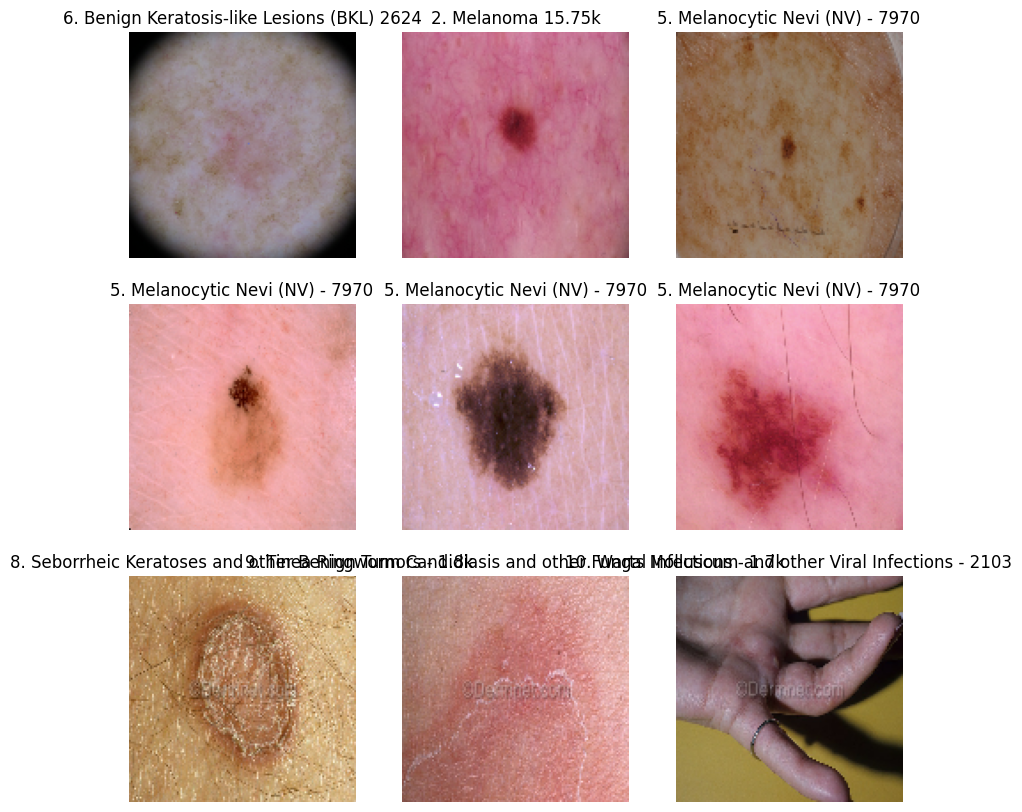

In [43]:
import matplotlib.pyplot as plt

# Get class names from the original dataset
class_names = dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in dataset_ds.take(50):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()
#printing few images

In [10]:
#normalizing the images, as these in 255 pixeld format
def normal(image,label):
  return image/255,label

dataset_ds = dataset.map(normal)

In [12]:
#downloading keras tuner for hyper perimeter tuning
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [19]:
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from tensorflow.keras.layers import (
    Conv2D, Dense, BatchNormalization, MaxPooling2D,
    Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential

#extracting best model for data

def buildmodel(hp):

    # Activation choices
    act_list = [
        "relu", "sigmoid", "tanh", "softplus", "softsign",
        "selu", "elu", "exponential", "linear", "gelu",
        "swish", "hard_sigmoid", "hard_swish"
    ]

    model = Sequential()

    # Block 1
    model.add(Conv2D(
        32, (3,3), padding='same',
        activation=hp.Choice("act1", act_list),
        input_shape=(128,128,3)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 2
    model.add(Conv2D(
        64, (3,3), padding='same',
        activation=hp.Choice("act2", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 3
    model.add(Conv2D(
        128, (3,3), padding='same',
        activation=hp.Choice("act3", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 4
    model.add(Conv2D(
        256, (3,3), padding='same',
        activation=hp.Choice("act4", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    model.add(Dropout(0.2))
    model.add(GlobalAveragePooling2D())

    # Dense Head
    model.add(Dense(
        256,
        activation=hp.Choice("dense_act", act_list)
    ))
    model.add(Dropout(0.2))

    # Output (always softmax)
    model.add(Dense(10, activation="softmax"))

    # Optimizer choices (valid in Keras)
    opt_name = hp.Choice(
        "optimizer",
        ["SGD", "RMSprop", "Adam", "AdamW", "Adagrad", "Adamax", "Nadam", "Ftrl"]
    )

    # map optimizer name to real object
    optimizer_dict = {
        "SGD": keras.optimizers.SGD(),
        "RMSprop": keras.optimizers.RMSprop(),
        "Adam": keras.optimizers.Adam(),
        "AdamW": keras.optimizers.AdamW(),
        "Adagrad": keras.optimizers.Adagrad(),
        "Adamax": keras.optimizers.Adamax(),
        "Nadam": keras.optimizers.Nadam(),
        "Ftrl": keras.optimizers.Ftrl(),
    }

    model.compile(
        optimizer=optimizer_dict[opt_name],
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [24]:
tuner = kt.RandomSearch(
    buildmodel,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="skin_cnn"

)


Reloading Tuner from tuner_dir/skin_cnn/tuner0.json


In [28]:
model = tuner.get_best_models(1)[0]
model.fit(dataset_ds,epochs = 20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


849/849 ━━━━━━━━━━━━━━━━━━━━ 111s 119ms/step - accuracy: 0.9041 - loss: 0.2636
Epoch 2/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 96s 113ms/step - accuracy: 0.9063 - loss: 0.2551
Epoch 3/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9072 - loss: 0.2507
Epoch 4/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 95s 111ms/step - accuracy: 0.9201 - loss: 0.2277
Epoch 5/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9240 - loss: 0.2082
Epoch 6/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 143s 111ms/step - accuracy: 0.9211 - loss: 0.2100
Epoch 7/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 111ms/step - accuracy: 0.9361 - loss: 0.1899
Epoch 8/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 111ms/step - accuracy: 0.9324 - loss: 0.1899
Epoch 9/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 143s 112ms/step - accuracy: 0.9343 - loss: 0.1789
Epoch 10/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9403 - loss: 0.1645
Epoch 11/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 142s 110ms/step - accuracy: 0.9363 - loss: 0.1746
Epoch 12/20
849/849 ━━━━━━

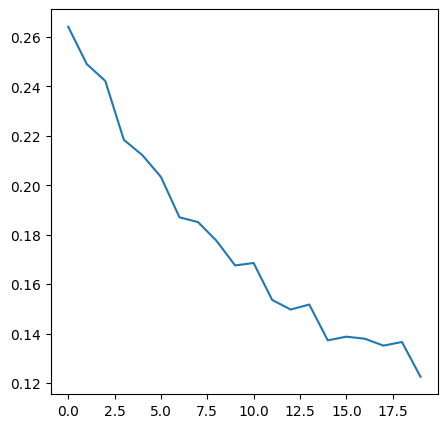

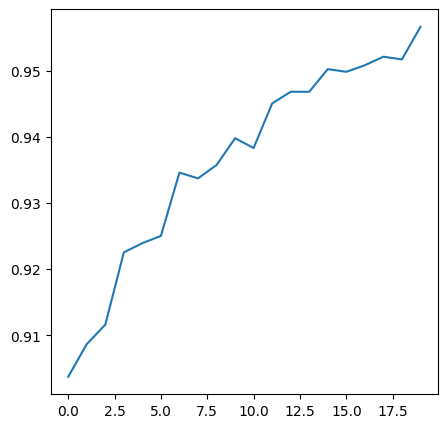

In [41]:
#plotting losses and accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.subplot(111)
plt.plot(model.history.history['loss'])
plt.show()
plt.figure(figsize=(5,5))
plt.subplot(111)
plt.plot(model.history.history['accuracy'])